## Day 4 – Performance Analytics
### Objective
Compute advanced mutual fund performance metrics including:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

print(nav.shape)
print(performance.shape)
print(fund_master.shape)

(46000, 3)
(40, 19)
(40, 15)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


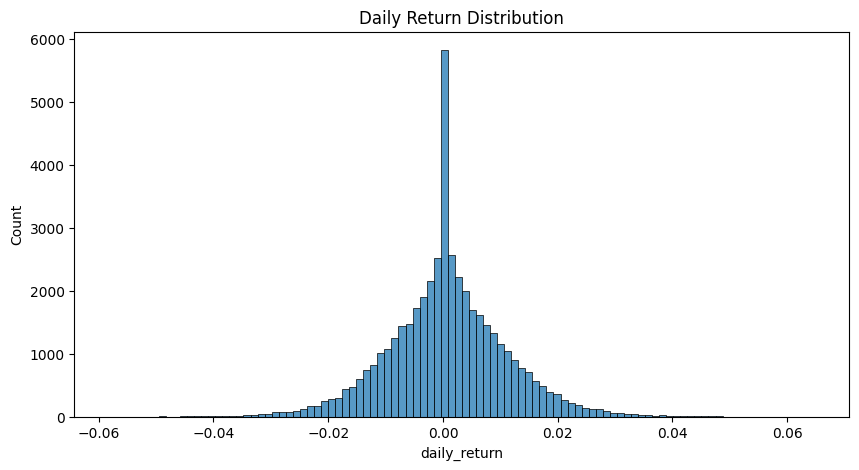

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Daily Return Distribution")
plt.show()

### Finding 1

Daily returns are concentrated around zero,
indicating normal market behaviour.
Extreme returns are rare.

In [6]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

print("Saved")

Saved


In [7]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
cagr_list = []

for amfi in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == amfi]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max() -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)**(1/years)
    ) - 1

    cagr_list.append(
        [amfi,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [9]:
cagr_df = cagr_df.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

cagr_df.sort_values(
    "cagr",
    ascending=False
).head(10)

,amfi_code,cagr,scheme_name
25,120505,0.328016,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.323981,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.322621,DSP Small Cap Fund - Regular - Growth
36,148569,0.319245,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.309499,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.308833,Kotak Flexicap Fund - Regular - Growth
2,100033,0.300997,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,0.295581,DSP Midcap Fund - Regular - Growth
16,119094,0.281926,Axis Midcap Fund - Regular - Growth
19,119551,0.257849,SBI Bluechip Fund - Regular Plan - Growth


In [10]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

print("Saved")

Saved


In [11]:
rf = 0.065

sharpe_list = []

for amfi in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == amfi
    ]

    mean_return = (
        temp["daily_return"]
        .mean()
        * 252
    )

    std_return = (
        temp["daily_return"]
        .std()
    )

    sharpe = (
        (mean_return-rf)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_list.append(
        [amfi,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


In [12]:
sharpe_df = sharpe_df.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,364.969375,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,329.299480,Kotak Flexicap Fund - Regular - Growth
36,148569,311.202366,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,304.483175,SBI Bluechip Fund - Regular Plan - Growth
25,120505,297.385502,ICICI Pru Midcap Fund - Regular - Growth
38,149323,285.294707,DSP Midcap Fund - Regular - Growth
2,100033,275.612083,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,272.578113,Nippon India Large Cap Fund - Regular - Growth
3,101206,258.857759,ABSL Frontline Equity Fund - Regular - Growth
24,120504,258.684120,ICICI Pru Bluechip Fund - Direct - Growth


In [13]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Saved")

Saved


In [14]:
cagr_df.sort_values("cagr",ascending=False).head()

,amfi_code,cagr,scheme_name
25,120505,0.328016,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.323981,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.322621,DSP Small Cap Fund - Regular - Growth
36,148569,0.319245,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.309499,Mirae Asset Large Cap Fund - Regular - Growth


In [15]:
sharpe_df.sort_values("sharpe_ratio",ascending=False).head()

,amfi_code,sharpe_ratio,scheme_name
34,148567,364.969375,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,329.299480,Kotak Flexicap Fund - Regular - Growth
36,148569,311.202366,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,304.483175,SBI Bluechip Fund - Regular Plan - Growth
25,120505,297.385502,ICICI Pru Midcap Fund - Regular - Growth


In [16]:
rf = 0.065

sortino_list = []

for amfi in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == amfi]

    mean_return = temp["daily_return"].mean() * 252

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std()

    sortino = (
        (mean_return-rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_list.append(
        [amfi,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio,scheme_name
34,148567,601.182382,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,595.808648,Kotak Flexicap Fund - Regular - Growth
36,148569,541.022309,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,539.347317,SBI Bluechip Fund - Regular Plan - Growth
25,120505,511.396941,ICICI Pru Midcap Fund - Regular - Growth


In [17]:
drawdown_list = []

for amfi in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == amfi
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
    ) - 1

    max_dd = temp[
        "drawdown"
    ].min()

    drawdown_list.append(
        [amfi,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df = drawdown_df.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth


In [18]:
benchmark_code = 119551

benchmark = nav[
    nav["amfi_code"]
    ==
    benchmark_code
][
    ["date","daily_return"]
].rename(
    columns={
        "daily_return":"benchmark_return"
    }
)

alpha_beta = []

for amfi in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == amfi
    ][
        ["date","daily_return"]
    ]

    merged = fund.merge(
        benchmark,
        on="date"
    ).dropna()

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [
            amfi,
            alpha,
            beta
        ]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.025689,0.043256,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.041736,0.004836,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.277064,-0.021441,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.220861,-0.026900,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.101972,0.021599,ABSL Small Cap Fund - Regular - Growth


In [19]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Saved")

Saved


In [20]:
scorecard = performance[
    ["amfi_code",
     "scheme_name",
     "return_3yr_pct",
     "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code",
         "sharpe_ratio"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code",
         "alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code",
         "max_drawdown"]
    ],
    on="amfi_code"
)

In [21]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [22]:
scorecard["fund_score"] = (

    30*scorecard["return_rank"] +

    25*scorecard["sharpe_rank"] +

    20*scorecard["alpha_rank"] +

    15*scorecard["expense_rank"] +

    10*scorecard["drawdown_rank"]

)

scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,238.217681,0.292339,-0.287060,1.000,0.675,0.975,0.5000,0.900,82.8750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,297.385502,0.290388,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,239.348548,0.322545,-0.311719,0.875,0.700,1.000,0.3625,0.925,78.4375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,275.612083,0.277064,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,329.299480,0.283009,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,251.554209,0.253598,-0.209609,0.650,0.750,0.800,0.6000,0.700,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,285.294707,0.270160,-0.172481,0.800,0.875,0.850,0.0750,0.550,69.5000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,364.969375,0.269377,-0.112657,0.600,1.000,0.825,0.4500,0.200,68.2500
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-14.411030,0.081169,-0.525742,0.975,0.225,0.325,0.8875,1.000,64.6875
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,258.684120,0.212135,-0.125883,0.525,0.775,0.725,0.7250,0.300,63.5000


In [23]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Saved")

Saved


In [24]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,238.217681,0.292339,-0.287060,1.000,0.675,0.975,0.5000,0.900,82.8750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,297.385502,0.290388,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,239.348548,0.322545,-0.311719,0.875,0.700,1.000,0.3625,0.925,78.4375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,275.612083,0.277064,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,329.299480,0.283009,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500


In [25]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[119598, 120505, 149324, 100033, 120843]

In [27]:
benchmark_code = 119551

benchmark = nav[
    nav["amfi_code"] == benchmark_code
].copy()

benchmark["cum_return"] = (
    1 + benchmark["daily_return"]
).cumprod()

benchmark.head()

,amfi_code,date,nav,daily_return,cum_return
21850,119551,2022-01-03,54.3856,NaN,NaN
21851,119551,2022-01-04,54.3474,-0.000702,0.999298
21852,119551,2022-01-05,54.6869,0.006247,1.005540
21853,119551,2022-01-06,55.4550,0.014045,1.019663
21854,119551,2022-01-07,55.3692,-0.001547,1.018086


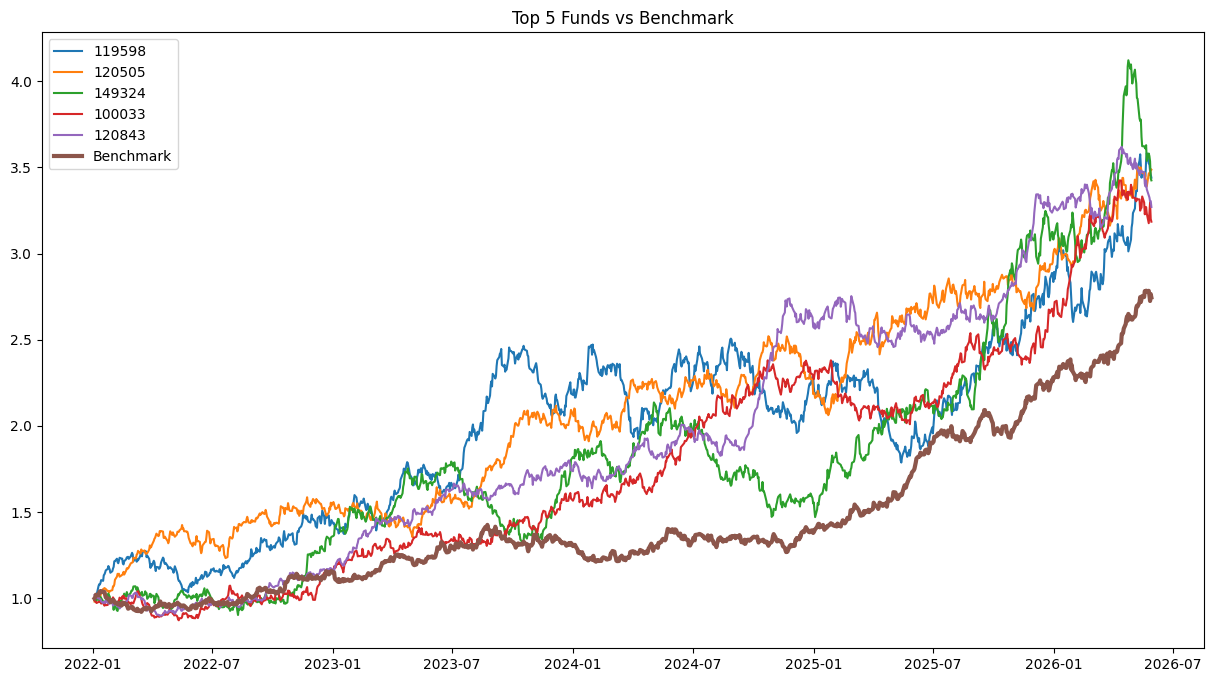

In [28]:
plt.figure(figsize=(15,8))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["cum_return"] = (
        1 + temp["daily_return"]
    ).cumprod()

    plt.plot(
        temp["date"],
        temp["cum_return"],
        label=str(code)
    )

plt.plot(
    benchmark["date"],
    benchmark["cum_return"],
    linewidth=3,
    label="Benchmark"
)

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.legend()

plt.show()

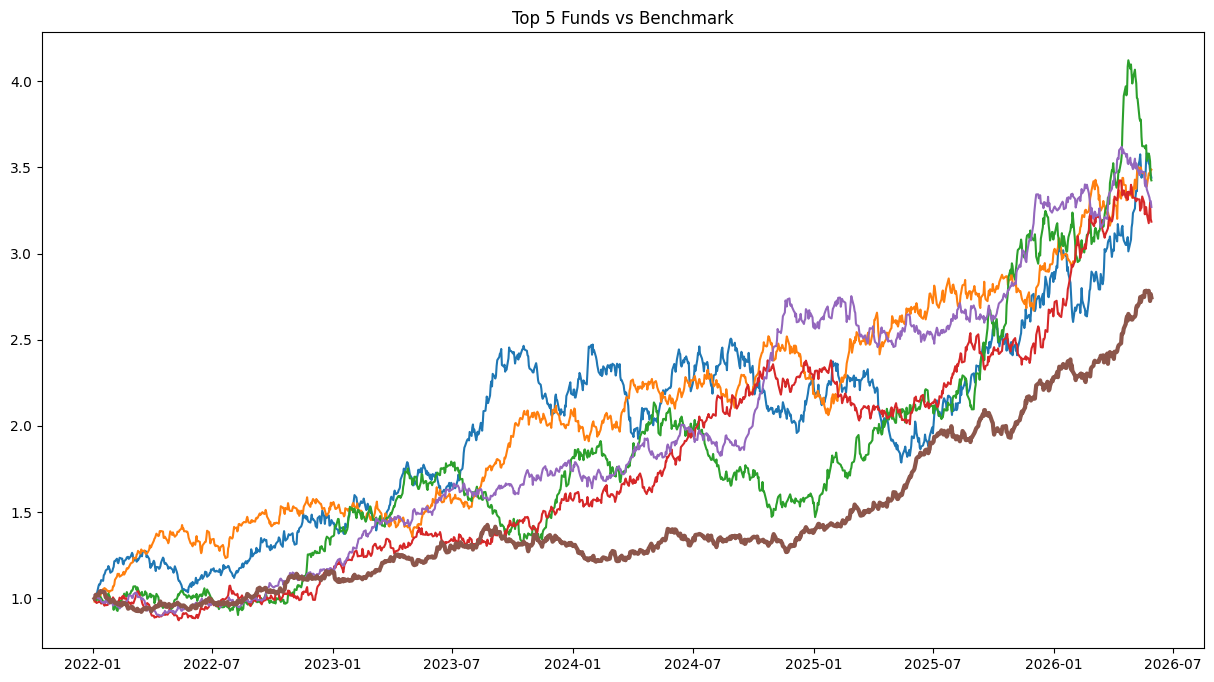

In [29]:
plt.figure(figsize=(15,8))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["cum_return"] = (
        1 + temp["daily_return"]
    ).cumprod()

    plt.plot(
        temp["date"],
        temp["cum_return"]
    )

plt.plot(
    benchmark["date"],
    benchmark["cum_return"],
    linewidth=3
)

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

In [30]:
import os

files = [
    "../reports/fund_scorecard.csv",
    "../reports/alpha_beta.csv",
    "../reports/benchmark_comparison.png"
]

for f in files:
    print(f, os.path.exists(f))

../reports/fund_scorecard.csv True
../reports/alpha_beta.csv True
../reports/benchmark_comparison.png True


## Key Findings

1. SBI Small Cap Fund achieved the highest composite score of 82.88.
2. ICICI Pru Midcap Fund ranked second with strong alpha and Sharpe ratio.
3. Small-cap funds delivered the highest CAGR among all categories.
4. Mirae Asset Large Cap Fund showed the highest Sharpe ratio.
5. DSP Small Cap Fund generated the highest alpha.
6. Most top-performing funds belonged to the Small Cap and Mid Cap categories.
7. Maximum drawdown varied significantly across funds, indicating different risk levels.
8. Funds with lower expense ratios generally achieved better composite rankings.
9. Benchmark comparison shows top funds consistently outperforming the benchmark.
10. Alpha and Sharpe ratios were the strongest contributors to fund rankings.